In [1]:
using Pkg
Pkg.activate("./../julia-code")

  Activating project at `~/code/compositional/julia-code`


In [8]:
using Meris
using DataFrames, StatsBase
using CairoMakie, MakiePublication, LaTeXStrings
using CSV, CodecZlib

include("./../julia-code/scripts/module-scripts/macropatterns/MacroPatterns.jl")
using .MacroPatterns

In [3]:
# Set theme for plots
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

In [5]:
df1 = CSV.read(Meris.GAIADIR * "clean_F-G-K_nbin_200_bmin_0.25_bmax_3.5.csv.gz", DataFrame)
df2 = CSV.read(Meris.GAIADIR * "clean_M_nbin_200_bmin_0.25_bmax_3.5.csv.gz", DataFrame)
df = vcat(df1, df2);

In [9]:
df.class .= "gaia"
Meris.DataTools.df_filter!(df; min_samples=20, min_nreads=5e3)

println("--- AFD ---")
afd = MacroPatterns.compute_AFD(df; occ=0.95, bins=25, verbose=true, save=false);

--- AFD ---
gaia


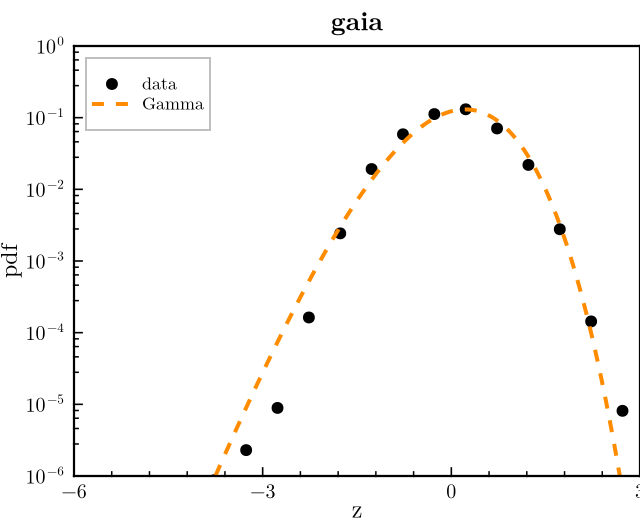

In [16]:
# Plot AFDs

# Collect environment names in a robust way
envs = afd isa AbstractDict ? collect(keys(afd)) : [e for (e, _) in afd]
nenv  = length(envs)

ncols = 4
if nenv == 1
    ncols =1
end
nrows = cld(nenv, ncols)            # ceil division
fig   = Figure(size=(320*ncols, 260*nrows))

# Global axis settings
xlims = (-6, 3)
ylims = (1e-6, 1e0)
zrange = -6:1e-2:3

for (i, e) in enumerate(envs)
    row = (i - 1) ÷ ncols + 1
    col = (i - 1) % ncols + 1
    ax = Axis(fig[row, col];
        title = string(e),
        yscale = log10,
        limits = (xlims, ylims),
        xlabel = L"\text{z}",
        ylabel = L"\text{pdf}",
        xlabelsize = 12, ylabelsize = 12, titlesize = 13,
        xticklabelsize = 10, yticklabelsize = 10
    )

    # Data for this environment
    x, y = afd isa AbstractDict ? afd[e] : only(last.(filter(p -> first(p) == e, afd)))

    # Plots
    scatter!(ax, x, 10 .^ log.(y); markersize=7, label="data", color=:black)

    lines!(ax, zrange, 10 .^ Meris.LRDistr.lr_gamma(zrange, 5);
           linewidth=2, linestyle=:dash, label="Gamma", color=:darkorange)
    
    # Legend inside each axis
    axislegend(ax; position=:lt, framevisible=true, labelsize=9, padding=3)
end

# Optional: tighten layout a bit
colgap!(fig.layout, 12)
rowgap!(fig.layout, 10)

fig


In [17]:
savefig("gaia_preliminary.png", fig)